# E-Commerce Analytics — Part 2: Customer Segmentation, Retention & Forecasting

**Author:** Nikhil Kumar  
**Input:** `data_cleaned.csv` — the analysis-ready dataset produced by **Part 1 (`product_analysis.ipynb`)**  
**Stack:** Python, pandas, NumPy, scikit-learn, Matplotlib, Seaborn

---

## Objective
Part 1 established that revenue is heavily concentrated by product and by geography. This notebook asks the
same question of the **customer base**, and turns the answer into segments a marketing team can act on.

## Contents
1. [Setup and data load](#setup)
2. [Customer-level feature engineering](#features)
3. [RFM analysis](#rfm) — Recency, Frequency, Monetary scoring and rule-based segments
4. [K-Means clustering](#kmeans) — data-driven segments, with k chosen by elbow + silhouette
5. [Cohort retention analysis](#cohort)
6. [Revenue concentration](#concentration)
7. [Revenue forecasting](#forecast) — validated against a hold-out period
8. [Insights and recommendations](#insights)

<a id="setup"></a>
## 1. Setup and data load

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (11, 5), "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.labelsize": 11,
})
ACCENT, ACCENT2, MUTED, RED, GREEN = "#2563eb", "#f59e0b", "#94a3b8", "#ef4444", "#16a34a"

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

CLEAN_PATH = "../data_cleaned.csv"
SEGMENT_PATH = "../customer_segments.csv"
VIEWS = "../views"
RANDOM_STATE = 42


def gbp(v, _=None):
    if abs(v) >= 1_000_000:
        return f"{v/1_000_000:,.1f}M"
    return f"{v/1_000:,.0f}k"


def summarise(frame, by):
    """Size, average RFM and revenue share per group. Used for both RFM segments and clusters."""
    out = frame.groupby(by).agg(
        customers=("recency", "size"),
        avg_recency=("recency", "mean"),
        avg_frequency=("frequency", "mean"),
        avg_monetary=("monetary", "mean"),
        total_revenue=("monetary", "sum"),
    ).round(1)
    out["% of customers"] = (out["customers"] / len(frame) * 100).round(1)
    out["% of revenue"] = (out["total_revenue"] / frame["monetary"].sum() * 100).round(1)
    return out


def share_bars(ax, left, right, left_label, right_label, headroom=1.18):
    """Side-by-side 'share of customers vs share of revenue' bars with value labels."""
    x, width = np.arange(len(left)), 0.38
    ax.bar(x - width / 2, left, width, color=MUTED, label=left_label)
    ax.bar(x + width / 2, right, width, color=ACCENT, label=right_label)
    tallest = max(max(left), max(right))
    for i, (lv, rv) in enumerate(zip(left, right)):
        ax.text(i - width / 2, lv + tallest * 0.02, f"{lv:.0f}%", ha="center", fontsize=9)
        ax.text(i + width / 2, rv + tallest * 0.02, f"{rv:.0f}%", ha="center", fontsize=9,
                fontweight="bold")
    ax.set(xticks=x, ylabel="%", ylim=(0, tallest * headroom))
    ax.legend(fontsize=9)

In [2]:
df = pd.read_csv(CLEAN_PATH, parse_dates=["InvoiceDate", "InvoiceDay"])

print(f"Rows: {len(df):,}   Customers: {df['CustomerID'].nunique():,}   "
      f"Orders: {df['InvoiceNo'].nunique():,}   Revenue: GBP {df['Revenue'].sum():,.0f}")
print(f"Period: {df['InvoiceDate'].min():%d %b %Y} to {df['InvoiceDate'].max():%d %b %Y}")

# All recency calculations need a fixed reference point. The dataset is historical,
# so "today" is the day after the last transaction, not the real current date.
SNAPSHOT = df["InvoiceDate"].max().normalize() + pd.Timedelta(days=1)
print(f"Snapshot date used for recency: {SNAPSHOT:%d %b %Y}")

Rows: 391,140   Customers: 4,333   Orders: 18,399   Revenue: GBP 8,456,824
Period: 01 Dec 2010 to 09 Dec 2011
Snapshot date used for recency: 10 Dec 2011


<a id="features"></a>
## 2. Customer-level feature engineering

The data is one row per line item. Every analysis below needs **one row per customer**, so the transaction log
is aggregated into a behavioural profile.

In [3]:
orders = df.groupby(["CustomerID", "InvoiceNo"]).agg(
    order_value=("Revenue", "sum"), order_date=("InvoiceDate", "min")).reset_index()

customers = df.groupby("CustomerID").agg(
    last_purchase=("InvoiceDate", "max"),
    first_purchase=("InvoiceDate", "min"),
    frequency=("InvoiceNo", "nunique"),
    monetary=("Revenue", "sum"),
    total_units=("Quantity", "sum"),
    unique_products=("StockCode", "nunique"),
    country=("Country", lambda s: s.mode().iat[0]),
)

customers["recency"] = (SNAPSHOT - customers["last_purchase"]).dt.days
customers["tenure"] = (SNAPSHOT - customers["first_purchase"]).dt.days
customers["avg_order_value"] = customers["monetary"] / customers["frequency"]
customers["is_repeat"] = customers["frequency"] > 1

# Average gap between consecutive orders (NaN for one-time buyers by definition)
orders = orders.sort_values(["CustomerID", "order_date"])
gap_days = orders.groupby("CustomerID")["order_date"].diff().dt.days
customers["avg_days_between_orders"] = gap_days.groupby(orders["CustomerID"]).mean()

customers = customers.drop(columns=["last_purchase", "first_purchase"])
print(f"Customer profiles built: {len(customers):,}")
customers.head()

Customer profiles built: 4,333


,frequency,monetary,total_units,unique_products,country,recency,tenure,avg_order_value,is_repeat,avg_days_between_orders
CustomerID,,,,,,,,,,
12347,7,4310.00,2458,103,Iceland,2,367,615.714286,True,60.333333
12348,4,1437.24,2332,21,Finland,75,358,359.310000,True,94.000000
12349,1,1457.55,630,72,Italy,18,18,1457.550000,False,NaN
12350,1,294.40,196,16,Norway,310,310,294.400000,False,NaN
12352,7,1385.74,526,57,Norway,36,296,197.962857,True,43.000000


In [4]:
customers[["recency", "frequency", "monetary", "avg_order_value",
           "unique_products", "tenure"]].describe().T.round(1)

,count,mean,std,min,25%,50%,75%,max
recency,4333.0,92.2,100.1,0.0,17.0,50.0,142.0,373.0
frequency,4333.0,4.2,7.6,1.0,1.0,2.0,5.0,206.0
monetary,4333.0,1951.7,8430.9,2.9,304.0,661.3,1628.6,279138.0
avg_order_value,4333.0,376.5,472.7,2.9,177.1,289.4,423.2,13305.5
unique_products,4333.0,61.4,85.3,1.0,16.0,35.0,77.0,1785.0
tenure,4333.0,222.8,117.8,0.0,112.0,248.0,326.0,373.0


The distributions are immediately informative. **Median frequency is well below the mean** and `monetary` has a
mean far above its median — both are the signature of a **right-skewed** customer base where a small group of
heavy buyers pulls the average up. That skew is why the clustering step later log-transforms these features
instead of feeding them in raw.

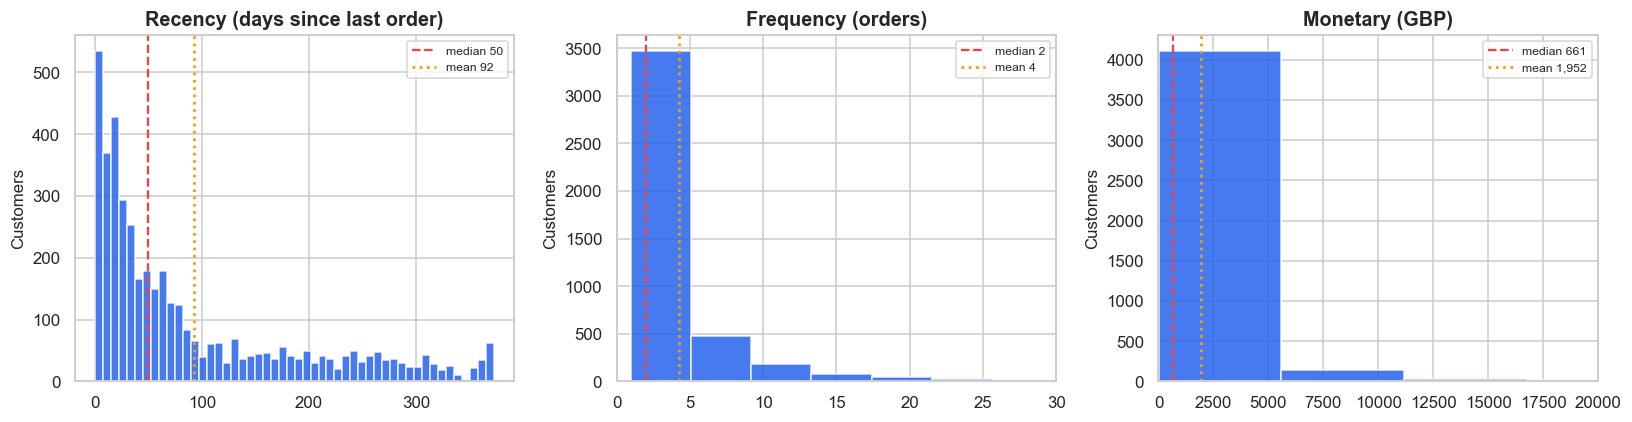

One-time buyers: 1,505 (34.7% of customers)
They contribute  GBP 549,425 (6.5% of revenue)


In [5]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, col, title in zip(ax, ["recency", "frequency", "monetary"],
                         ["Recency (days since last order)", "Frequency (orders)", "Monetary (GBP)"]):
    a.hist(customers[col], bins=50, color=ACCENT, alpha=0.85)
    a.axvline(customers[col].median(), color=RED, ls="--", lw=1.5,
              label=f"median {customers[col].median():,.0f}")
    a.axvline(customers[col].mean(), color=ACCENT2, ls=":", lw=1.8,
              label=f"mean {customers[col].mean():,.0f}")
    a.set(title=title, ylabel="Customers")
    a.legend(fontsize=8)
ax[1].set_xlim(0, 30)
ax[2].set_xlim(0, 20_000)
plt.tight_layout()
plt.show()

print(f"One-time buyers: {(~customers['is_repeat']).sum():,} "
      f"({(~customers['is_repeat']).mean():.1%} of customers)")
print(f"They contribute  GBP {customers.loc[~customers['is_repeat'], 'monetary'].sum():,.0f} "
      f"({customers.loc[~customers['is_repeat'], 'monetary'].sum()/customers['monetary'].sum():.1%} of revenue)")

<a id="rfm"></a>
## 3. RFM analysis

**RFM** scores each customer on three axes that together predict future value better than revenue alone:

| Axis | Question | Metric |
|:---|:---|:---|
| **Recency** | How recently did they buy? | days since last order (*lower is better*) |
| **Frequency** | How often do they buy? | distinct orders |
| **Monetary** | How much do they spend? | total revenue |

Each axis is scored **1-5 using quintiles**, so scores are relative to this customer base rather than to
arbitrary thresholds. Recency is scored in reverse, since recent activity is the desirable outcome.

In [6]:
rfm = customers[["recency", "frequency", "monetary"]].copy()

# Quintile scoring. Frequency is heavily tied (many customers share the same order count),
# so rank(method="first") is used to break ties and keep the five bins non-empty.
rfm["R"] = pd.qcut(rfm["recency"], 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm["F"] = pd.qcut(rfm["frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["M"] = pd.qcut(rfm["monetary"], 5, labels=[1, 2, 3, 4, 5]).astype(int)

rfm["RFM_score"] = rfm["R"] + rfm["F"] + rfm["M"]
rfm["RFM_cell"] = rfm["R"].astype(str) + rfm["F"].astype(str) + rfm["M"].astype(str)

print("Score range:", rfm["RFM_score"].min(), "to", rfm["RFM_score"].max())
rfm.head()

Score range: 3 to 15


,recency,frequency,monetary,R,F,M,RFM_score,RFM_cell
CustomerID,,,,,,,,
12347,2,7,4310.00,5,5,5,15,555
12348,75,4,1437.24,2,4,4,10,244
12349,18,1,1457.55,4,1,4,9,414
12350,310,1,294.40,1,1,2,4,112
12352,36,7,1385.74,3,5,4,12,354


In [7]:
def label_segment(r, f):
    """Map Recency and Frequency scores to standard, action-oriented segment names."""
    if r >= 4 and f >= 4:
        return "Champions"
    if r >= 3 and f >= 3:
        return "Loyal"
    if r >= 4 and f <= 2:
        return "New / Promising"
    if r == 3 and f <= 2:
        return "Needs Attention"
    if r <= 2 and f >= 4:
        return "At Risk"
    if r <= 2 and f == 3:
        return "Hibernating"
    return "Lost"


rfm["segment"] = [label_segment(r, f) for r, f in zip(rfm["R"], rfm["F"])]

segment_summary = summarise(rfm, "segment").sort_values("total_revenue", ascending=False)
segment_summary

,customers,avg_recency,avg_frequency,avg_monetary,total_revenue,% of customers,% of revenue
segment,,,,,,,
Champions,1125,12.6,10.0,5143.8,5786793.7,26.0,68.4
Loyal,824,37.1,3.7,1411.7,1163257.5,19.0,13.8
Lost,1073,217.0,1.1,406.6,436312.2,24.8,5.2
At Risk,280,135.0,4.9,1556.7,435881.7,6.5,5.2
Hibernating,371,162.7,2.3,908.3,336987.2,8.6,4.0
Needs Attention,348,52.5,1.1,469.3,163326.1,8.0,1.9
New / Promising,312,17.8,1.2,430.3,134265.2,7.2,1.6


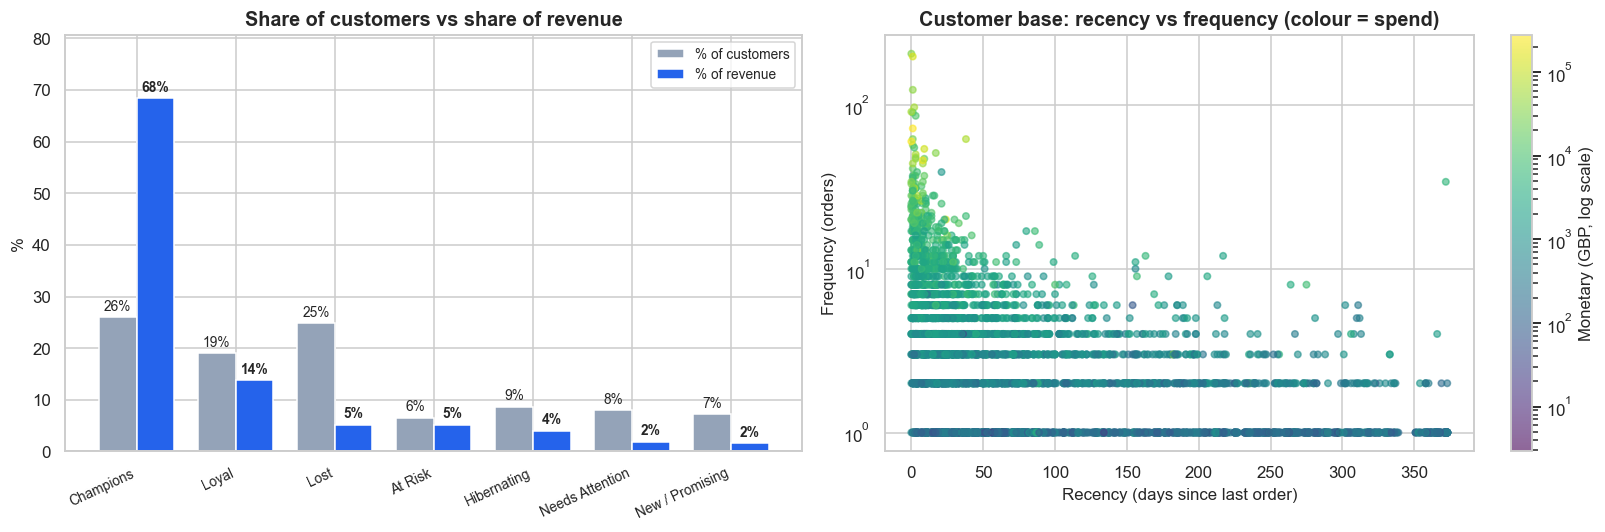

Largest revenue segment: Champions -> 26.0% of customers, 68.4% of revenue


In [8]:
order = segment_summary.index.tolist()

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

share_bars(ax[0], segment_summary["% of customers"], segment_summary["% of revenue"],
           "% of customers", "% of revenue")
ax[0].set(title="Share of customers vs share of revenue")
ax[0].set_xticklabels(order, rotation=25, ha="right", fontsize=9)

sc = ax[1].scatter(rfm["recency"], rfm["frequency"], c=rfm["monetary"], cmap="viridis",
                   s=18, alpha=0.6, norm=plt.matplotlib.colors.LogNorm())
ax[1].set(title="Customer base: recency vs frequency (colour = spend)",
          xlabel="Recency (days since last order)", ylabel="Frequency (orders)", yscale="log")
plt.colorbar(sc, ax=ax[1], label="Monetary (GBP, log scale)")

plt.tight_layout()
plt.savefig(f"{VIEWS}/customer_segments.png")
plt.show()

top = segment_summary.iloc[0]
print(f"Largest revenue segment: {segment_summary.index[0]} -> "
      f"{top['% of customers']}% of customers, {top['% of revenue']}% of revenue")

The gap between the grey and blue bars is the whole point of segmenting. **Champions are 26% of the base but
68% of revenue**, while **Lost** customers are almost as numerous (25%) and contribute **5%**. The scatter shows
the same structure continuously: high-frequency customers cluster at low recency, and spend rises with frequency.

Two segments deserve immediate attention for opposite reasons:

- **Champions (26% of customers, 68% of revenue)** — the revenue base. Protecting these accounts matters more
  than acquiring new ones, because losing one costs many marginal customers to replace.
- **At Risk (6.5% of customers)** — only 280 customers, but they average **4.9 orders and £1,557 spend** with
  recency slipping to **135 days**. They have *proven* they buy repeatedly and have now stopped, which makes them
  the highest expected return per contact of any group.

By contrast **New / Promising** and **Needs Attention** both average ~1.1-1.2 orders: they have bought once and
not yet returned. That is a conversion problem, not a retention problem, and section 5 quantifies it.

<a id="kmeans"></a>
## 4. K-Means clustering

RFM segments above use *fixed business rules*. K-Means instead lets the data define the groups, which can
surface structure the rules miss. Two preprocessing steps are required:

1. **Log-transform** — R, F and M are strongly right-skewed; K-Means minimises squared Euclidean distance and
   would otherwise let a few extreme spenders dominate every centroid.
2. **Standardise** — the three features have completely different units (days, counts, pounds), so without
   scaling `monetary` alone would decide the clusters.

In [9]:
X = pd.DataFrame({
    "recency": np.log1p(rfm["recency"]),
    "frequency": np.log1p(rfm["frequency"]),
    "monetary": np.log1p(rfm["monetary"]),
})

print("Skew before log transform:")
print(rfm[["recency", "frequency", "monetary"]].skew().round(2).to_string())
print("\nSkew after log transform:")
print(X.skew().round(2).to_string())

X_scaled = StandardScaler().fit_transform(X)
print("\nScaled matrix:", X_scaled.shape)

Skew before log transform:
recency       1.24
frequency    11.95
monetary     21.10

Skew after log transform:
recency     -0.47
frequency    1.21
monetary     0.36

Scaled matrix: (4333, 3)


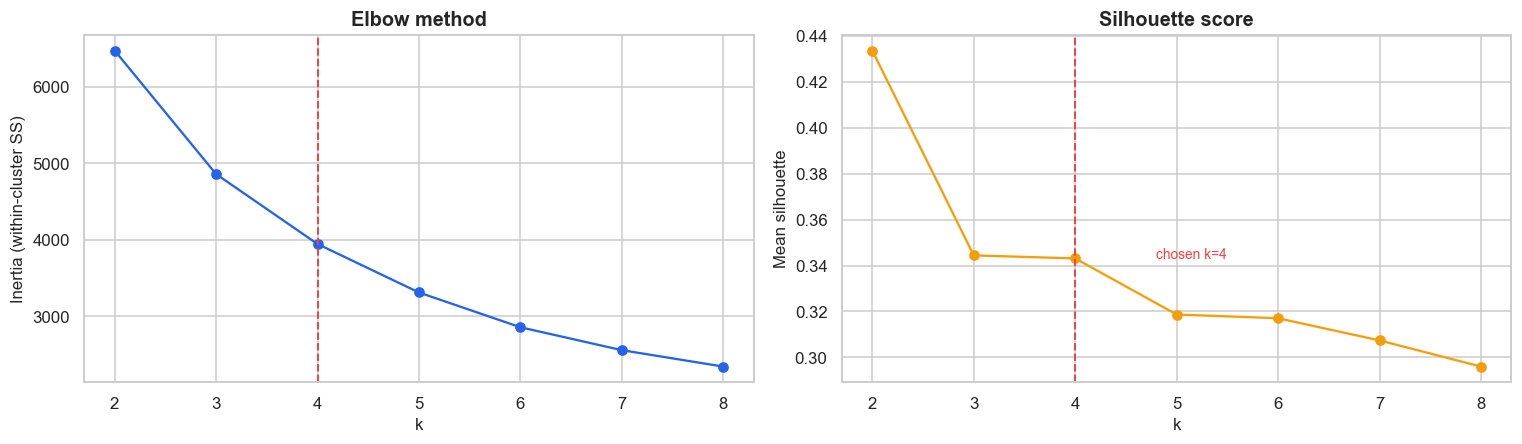

 k  inertia  silhouette
 2   6472.0       0.434
 3   4857.0       0.344
 4   3944.0       0.343
 5   3310.0       0.319
 6   2855.0       0.317
 7   2556.0       0.307
 8   2341.0       0.296


In [10]:
# Choose k with two independent criteria rather than by eye alone
ks = range(2, 9)
inertia, silhouette = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_scaled)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(X_scaled, km.labels_, sample_size=2000,
                                       random_state=RANDOM_STATE))

fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
ax[0].plot(list(ks), inertia, marker="o", color=ACCENT)
ax[0].set(title="Elbow method", xlabel="k", ylabel="Inertia (within-cluster SS)")
ax[1].plot(list(ks), silhouette, marker="o", color=ACCENT2)
ax[1].set(title="Silhouette score", xlabel="k", ylabel="Mean silhouette")

BEST_K = 4
for a in ax:
    a.axvline(BEST_K, color=RED, ls="--", lw=1.3)
ax[1].annotate(f"chosen k={BEST_K}", xy=(BEST_K, silhouette[BEST_K - 2]),
               xytext=(BEST_K + 0.8, silhouette[BEST_K - 2]), fontsize=9, color=RED)
plt.tight_layout()
plt.show()

print(pd.DataFrame({"k": list(ks), "inertia": np.round(inertia), "silhouette": np.round(silhouette, 3)})
        .to_string(index=False))

The two criteria disagree, which is worth being explicit about rather than glossing over. **Silhouette peaks at
k=2 (0.434)** — but that split only separates "active" from "dormant", which the business already knows and
cannot act on differently. From k=3 onward the score is essentially flat (**0.344 at k=3, 0.343 at k=4**), so
silhouette gives no real reason to prefer one over the other.

The elbow flattens around **k=4**, and k=4 produces four groups that map onto distinct commercial treatments
(protect / re-activate / develop / deprioritise). Since the statistical criteria are indifferent between k=3 and
k=4, **k=4 is chosen on actionability** — the deciding factor is stated openly rather than dressed up as a
purely statistical result.

In [11]:
kmeans = KMeans(n_clusters=BEST_K, random_state=RANDOM_STATE, n_init=10)
rfm["cluster"] = kmeans.fit_predict(X_scaled)

profile = summarise(rfm, "cluster")
profile["revenue_per_customer"] = (profile["total_revenue"] / profile["customers"]).round(0)
profile.sort_values("avg_monetary", ascending=False)

,customers,avg_recency,avg_frequency,avg_monetary,total_revenue,% of customers,% of revenue,revenue_per_customer
cluster,,,,,,,,
2,686,11.3,14.0,7919.8,5433010.0,15.8,64.2,7920.0
1,1183,68.5,4.1,1698.8,2009700.4,27.3,23.8,1699.0
3,811,16.9,2.2,550.1,446157.7,18.7,5.3,550.0
0,1653,179.8,1.3,343.6,567955.5,38.1,6.7,344.0


In [12]:
# Name clusters from their own statistics so labels stay correct if the data changes
ranked = profile["avg_monetary"].sort_values(ascending=False).index.tolist()
median_recency = rfm["recency"].median()


def cluster_name(cid):
    if cid == ranked[0]:
        return "High-Value Loyal"
    if cid == ranked[-1]:
        return "Dormant Low-Value"
    if profile.loc[cid, "avg_recency"] <= median_recency:
        return "Active Mid-Value"
    return "Lapsing Mid-Value"


names = {cid: cluster_name(cid) for cid in ranked}
rfm["cluster_name"] = rfm["cluster"].map(names)
profile["name"] = pd.Series(names)

print("Cluster labels derived from cluster statistics:")
for cid in ranked:
    p = profile.loc[cid]
    print(f"  Cluster {cid} -> {p['name']:<18} "
          f"recency {p['avg_recency']:>5.0f}d | frequency {p['avg_frequency']:>4.1f} | "
          f"spend GBP {p['avg_monetary']:>8,.0f} | {p['% of customers']:>4.1f}% of base | "
          f"{p['% of revenue']:>4.1f}% of revenue")

Cluster labels derived from cluster statistics:
  Cluster 2 -> High-Value Loyal   recency    11d | frequency 14.0 | spend GBP    7,920 | 15.8% of base | 64.2% of revenue
  Cluster 1 -> Lapsing Mid-Value  recency    68d | frequency  4.1 | spend GBP    1,699 | 27.3% of base | 23.8% of revenue
  Cluster 3 -> Active Mid-Value   recency    17d | frequency  2.2 | spend GBP      550 | 18.7% of base |  5.3% of revenue
  Cluster 0 -> Dormant Low-Value  recency   180d | frequency  1.3 | spend GBP      344 | 38.1% of base |  6.7% of revenue


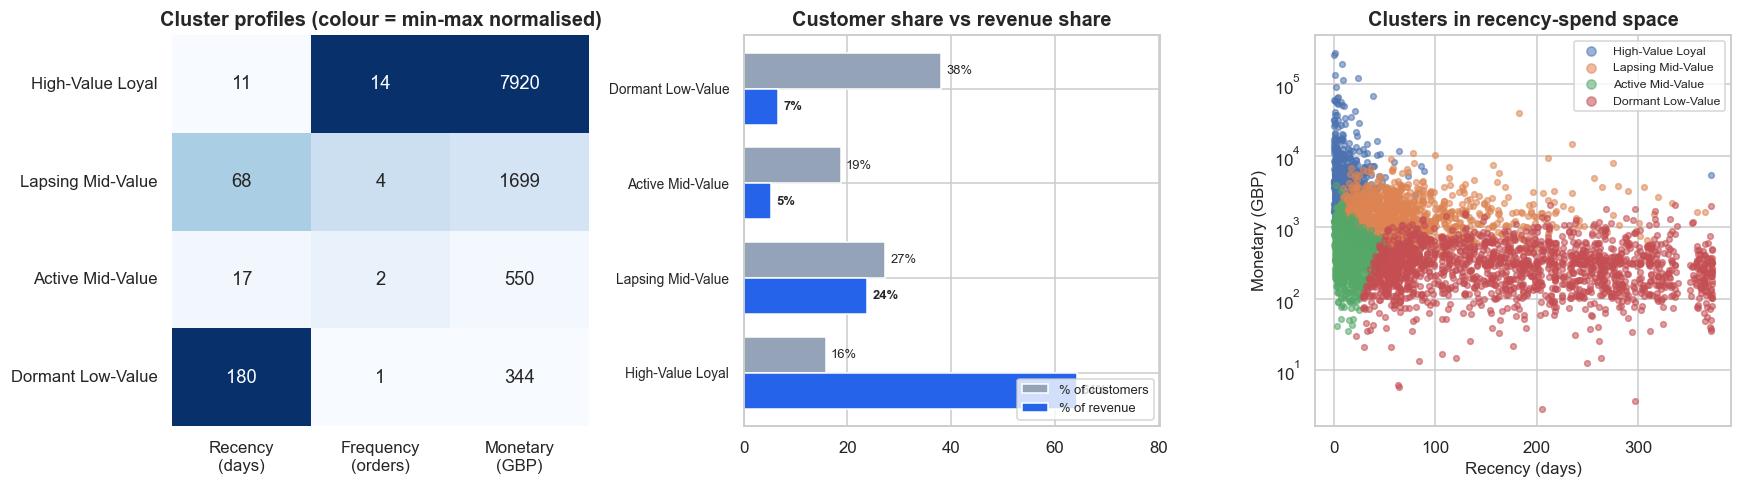

In [13]:
plot_order = ranked
labels = [names[c] for c in plot_order]

fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))

# Normalised centroid profile makes the three axes comparable on one chart
heat = profile.loc[plot_order, ["avg_recency", "avg_frequency", "avg_monetary"]]
heat_norm = (heat - heat.min()) / (heat.max() - heat.min())
sns.heatmap(heat_norm, annot=heat.round(0), fmt="g", cmap="Blues", cbar=False,
            yticklabels=labels, ax=ax[0],
            xticklabels=["Recency\n(days)", "Frequency\n(orders)", "Monetary\n(GBP)"])
ax[0].set(title="Cluster profiles (colour = min-max normalised)", ylabel="")
ax[0].tick_params(axis="y", rotation=0)

sizes = profile.loc[plot_order, "% of customers"]
revs = profile.loc[plot_order, "% of revenue"]
y, w = np.arange(len(plot_order)), 0.38
ax[1].barh(y + w/2, sizes, w, color=MUTED, label="% of customers")
ax[1].barh(y - w/2, revs, w, color=ACCENT, label="% of revenue")
for i, (s, r) in enumerate(zip(sizes, revs)):
    ax[1].text(s + 1, i + w/2, f"{s:.0f}%", va="center", fontsize=8.5)
    ax[1].text(r + 1, i - w/2, f"{r:.0f}%", va="center", fontsize=8.5, fontweight="bold")
ax[1].set(title="Customer share vs revenue share", yticks=y, xlim=(0, max(sizes.max(), revs.max()) * 1.25))
ax[1].set_yticklabels(labels, fontsize=9)
ax[1].legend(fontsize=8.5, loc="lower right")

for cid in plot_order:
    sub = rfm[rfm["cluster"] == cid]
    ax[2].scatter(sub["recency"], sub["monetary"], s=14, alpha=0.55, label=names[cid])
ax[2].set(title="Clusters in recency-spend space", xlabel="Recency (days)",
          ylabel="Monetary (GBP)", yscale="log")
ax[2].legend(fontsize=8, markerscale=1.6)

plt.tight_layout()
plt.savefig(f"{VIEWS}/cluster_profiles.png")
plt.show()

In [14]:
# Do the rule-based RFM segments and the unsupervised clusters agree?
crosstab = pd.crosstab(rfm["cluster_name"], rfm["segment"])
crosstab

segment,At Risk,Champions,Hibernating,Lost,Loyal,Needs Attention,New / Promising
cluster_name,,,,,,,
Active Mid-Value,0,174,0,0,312,35,290
Dormant Low-Value,37,0,254,1030,52,267,13
High-Value Loyal,5,652,0,0,29,0,0
Lapsing Mid-Value,238,299,117,43,431,46,9


The cross-tab shows the two approaches largely agree — the **High-Value Loyal** cluster is dominated by
Champions and Loyal customers, while the **Dormant** cluster absorbs Lost and Hibernating. That agreement is a
useful validation: two independent methods, one rule-based and one unsupervised, recover the same underlying
structure. K-Means adds a *continuous* view (it separates mid-value customers by how recently they lapsed),
whereas the RFM labels are easier to hand to a marketing team.

<a id="cohort"></a>
## 5. Cohort retention analysis

Segments describe the customer base *as it is today*. Cohort analysis asks a different question: **do customers
acquired in a given month keep coming back?** Each customer is assigned to the month of their first purchase,
then tracked over subsequent months.

In [15]:
df["order_month"] = df["InvoiceDate"].dt.to_period("M")
df["cohort_month"] = df.groupby("CustomerID")["InvoiceDate"].transform("min").dt.to_period("M")
df["cohort_index"] = ((df["order_month"] - df["cohort_month"]).apply(lambda x: x.n))

cohort_counts = (df.groupby(["cohort_month", "cohort_index"])["CustomerID"].nunique()
                   .unstack("cohort_index"))
cohort_sizes = cohort_counts.iloc[:, 0]
retention = cohort_counts.divide(cohort_sizes, axis=0) * 100

print("Cohort sizes (customers acquired per month):")
print(cohort_sizes.astype(int).to_string())
retention.round(1)

Cohort sizes (customers acquired per month):
cohort_month
2010-12    884
2011-01    415
2011-02    380
2011-03    452
2011-04    300
2011-05    284
2011-06    242
2011-07    187
2011-08    169
2011-09    299
2011-10    357
2011-11    323
2011-12     41
Freq: M


cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12
cohort_month,,,,,,,,,,,,,
2010-12,100.0,36.5,32.4,38.3,36.2,39.8,36.2,34.8,35.3,39.5,37.3,50.2,26.5
2011-01,100.0,21.9,26.7,22.9,31.8,28.9,24.8,24.1,29.6,32.8,36.6,11.8,NaN
2011-02,100.0,18.7,18.7,28.7,27.1,24.5,25.5,27.4,24.7,30.5,6.8,NaN,NaN
2011-03,100.0,14.8,25.2,19.9,22.3,16.8,26.8,23.0,27.9,8.6,NaN,NaN,NaN
2011-04,100.0,21.0,20.3,21.0,19.7,22.7,21.7,26.0,7.3,NaN,NaN,NaN,NaN
2011-05,100.0,19.0,17.3,17.3,20.8,23.2,26.4,9.2,NaN,NaN,NaN,NaN,NaN
2011-06,100.0,17.4,15.7,26.4,23.1,33.1,9.5,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,100.0,17.6,20.3,22.5,27.3,11.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,100.0,20.1,24.3,24.3,12.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


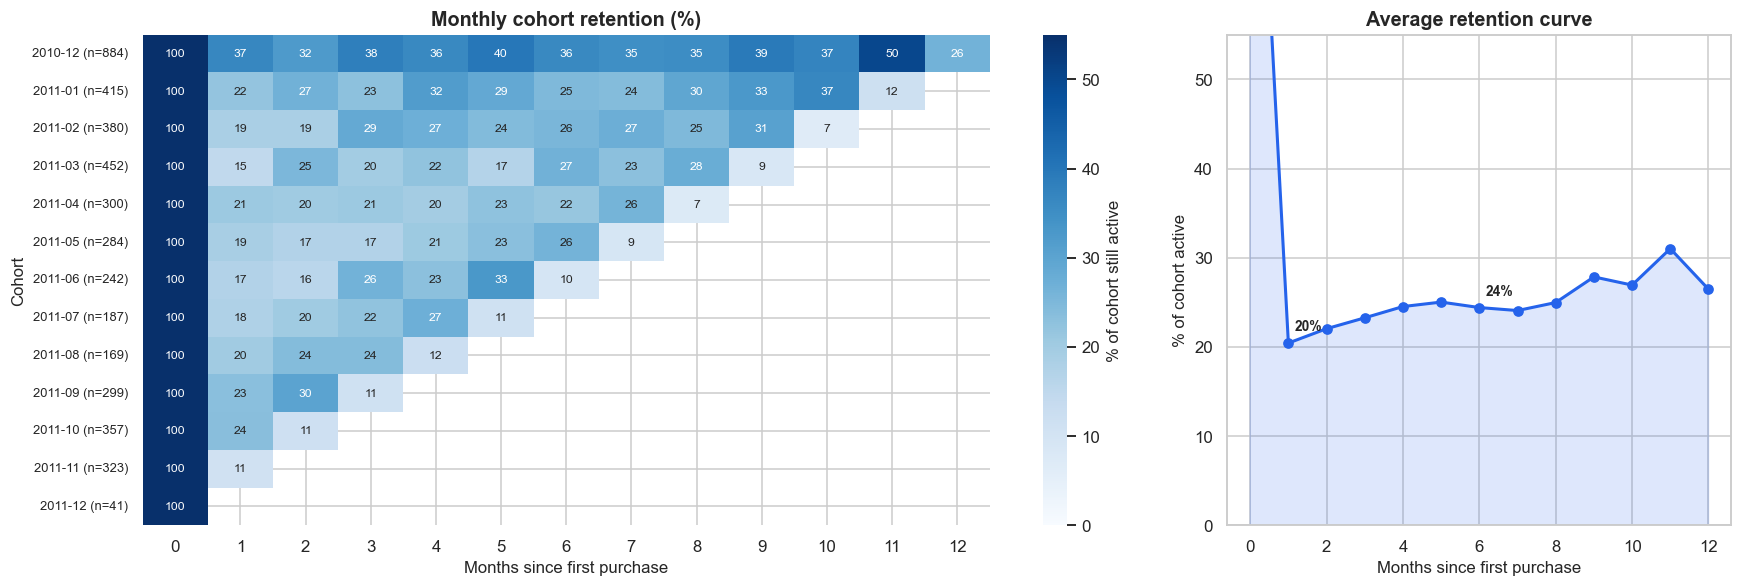

Month-1 retention (average across cohorts): 20.4%
Month-6 retention (average across cohorts): 24.4%
Dec-2010 cohort still active after 11 months: 50.2%


In [16]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5.5), gridspec_kw={"width_ratios": [2.1, 1]})

mask = retention.isna()
sns.heatmap(retention, annot=True, fmt=".0f", cmap="Blues", mask=mask, ax=ax[0],
            cbar_kws={"label": "% of cohort still active"}, annot_kws={"size": 8},
            vmin=0, vmax=55)
ax[0].set(title="Monthly cohort retention (%)", xlabel="Months since first purchase", ylabel="Cohort")
ax[0].set_yticklabels([f"{p} (n={int(cohort_sizes[p])})" for p in retention.index],
                      rotation=0, fontsize=8.5)

avg_curve = retention.mean()
ax[1].plot(avg_curve.index, avg_curve.values, marker="o", color=ACCENT, lw=2)
ax[1].fill_between(avg_curve.index, avg_curve.values, alpha=0.15, color=ACCENT)
for i in [1, min(6, len(avg_curve) - 1)]:
    ax[1].annotate(f"{avg_curve.iloc[i]:.0f}%", (avg_curve.index[i], avg_curve.iloc[i]),
                   textcoords="offset points", xytext=(4, 8), fontsize=9, fontweight="bold")
ax[1].set(title="Average retention curve", xlabel="Months since first purchase",
          ylabel="% of cohort active", ylim=(0, 55))

plt.tight_layout()
plt.savefig(f"{VIEWS}/cohort_analysis.png")
plt.show()

print(f"Month-1 retention (average across cohorts): {avg_curve.iloc[1]:.1f}%")
print(f"Month-6 retention (average across cohorts): {avg_curve.iloc[6]:.1f}%")
print(f"Dec-2010 cohort still active after 11 months: {retention.iloc[0, 11]:.1f}%")

Three things stand out.

**The month-1 cliff is the main leak.** Retention falls from 100% to **~20% in the first month** — roughly four
in five new customers do not come back the following month, consistent with the 35% one-time-buyer share from
section 2. This single transition is the weakest link in the funnel, which makes a **post-first-purchase
onboarding sequence** the highest-leverage intervention available.

**Retention then stabilises instead of decaying to zero.** Beyond month 1 the curve flattens in the **20-25%**
band and the month-6 average (**24%**) is actually *above* month-1. Customers who survive the first month become
genuinely durable, so the payoff from fixing that first transition compounds.

**The Dec-2010 cohort outperforms every later one**, holding **50% at month 11**. Some of that is real, but some
is structural: it is the oldest cohort, acquired in a peak trading month, and the only one observed over a full
year. Comparing it directly to a September cohort would not be fair.

Two reading caveats: the right-hand columns rest on progressively fewer cohorts, and the **final diagonal is
depressed by truncation** — December 2011 contains only 9 days of data, so those last values (6-12%) reflect a
short window, not a collapse in loyalty.

<a id="concentration"></a>
## 6. Revenue concentration

Part 1 found that 22% of products drive 80% of revenue. Does the customer base follow the same rule?

In [17]:
sorted_rev = customers["monetary"].sort_values(ascending=False)
cum_share = sorted_rev.cumsum() / sorted_rev.sum() * 100
cust_share = np.arange(1, len(sorted_rev) + 1) / len(sorted_rev) * 100

for pct in [1, 5, 10, 20, 50]:
    idx = int(len(sorted_rev) * pct / 100) - 1
    print(f"Top {pct:>2}% of customers -> {cum_share.iloc[idx]:>5.1f}% of revenue")

pareto_point = np.argmax(cum_share.values >= 80) + 1
print(f"\n80% of revenue comes from the top {pareto_point:,} customers "
      f"({pareto_point/len(sorted_rev):.1%} of the base)")

Top  1% of customers ->  30.2% of revenue
Top  5% of customers ->  48.9% of revenue
Top 10% of customers ->  60.2% of revenue
Top 20% of customers ->  73.8% of revenue
Top 50% of customers ->  91.9% of revenue

80% of revenue comes from the top 1,167 customers (26.9% of the base)


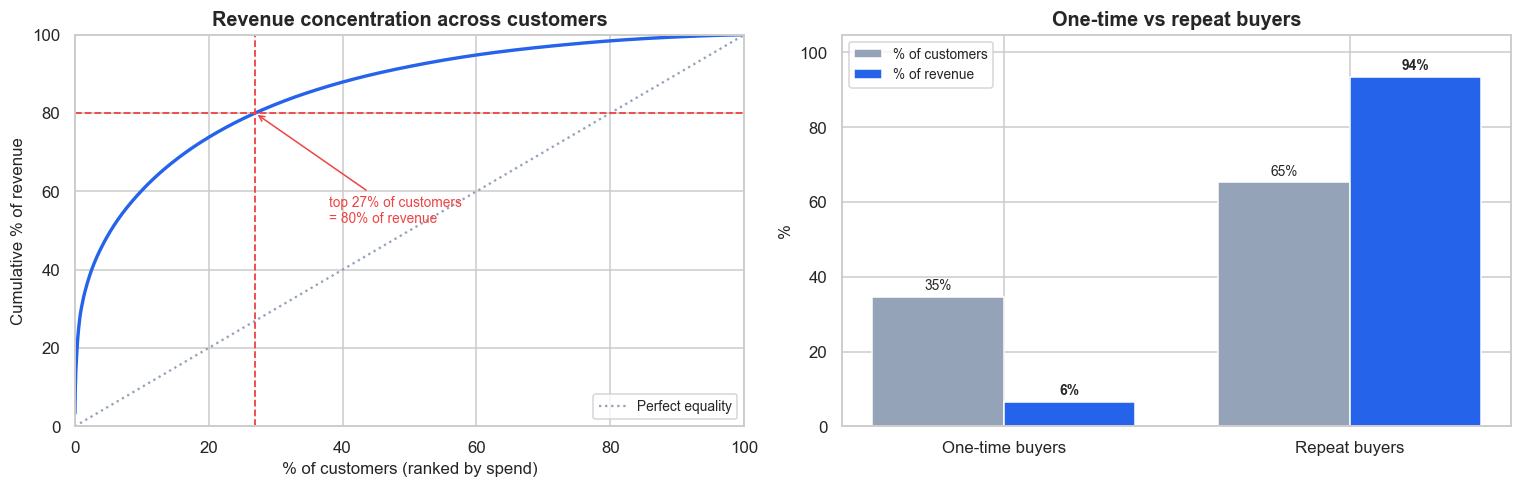

,customers,revenue,avg_order_value,% of customers,% of revenue
One-time buyers,1505,549425.2,365.1,34.7,6.5
Repeat buyers,2828,7907398.4,382.7,65.3,93.5


In [18]:
repeat = customers.groupby("is_repeat").agg(
    customers=("monetary", "size"), revenue=("monetary", "sum"),
    avg_order_value=("avg_order_value", "mean"))
repeat.index = ["One-time buyers", "Repeat buyers"]
repeat["% of customers"] = (repeat["customers"] / repeat["customers"].sum() * 100).round(1)
repeat["% of revenue"] = (repeat["revenue"] / repeat["revenue"].sum() * 100).round(1)

fig, ax = plt.subplots(1, 2, figsize=(14, 4.6))

ax[0].plot(cust_share, cum_share.values, color=ACCENT, lw=2.2)
ax[0].plot([0, 100], [0, 100], ls=":", color=MUTED, label="Perfect equality")
ax[0].axhline(80, color=RED, ls="--", lw=1.2)
ax[0].axvline(pareto_point / len(sorted_rev) * 100, color=RED, ls="--", lw=1.2)
ax[0].annotate(f"top {pareto_point/len(sorted_rev):.0%} of customers\n= 80% of revenue",
               xy=(pareto_point / len(sorted_rev) * 100, 80), xytext=(38, 52), fontsize=9, color=RED,
               arrowprops=dict(arrowstyle="->", color=RED))
ax[0].set(title="Revenue concentration across customers", xlabel="% of customers (ranked by spend)",
          ylabel="Cumulative % of revenue", xlim=(0, 100), ylim=(0, 100))
ax[0].legend(fontsize=9, loc="lower right")

share_bars(ax[1], repeat["% of customers"], repeat["% of revenue"],
           "% of customers", "% of revenue", headroom=1.12)
ax[1].set(title="One-time vs repeat buyers", xticklabels=repeat.index)

plt.tight_layout()
plt.show()
repeat.round(1)

The customer base is **almost exactly as concentrated as the product catalogue**: 80% of revenue comes from the
top **27% of customers**, against 22% of products in Part 1. The top **1% alone contributes 30%** of revenue, and
the top 10% contributes 60%.

The repeat/one-time split is just as stark: **one-time buyers are 35% of customers but only 6.5% of revenue**,
while repeat buyers deliver **93.5%**. Notably their *average order values are nearly identical* (£365 vs £383) —
one-time buyers are not smaller spenders per order, they simply never place a second one. The problem is
**frequency, not basket size**, which is good news because frequency responds to lifecycle marketing.

Together these justify concentrating retention budget at the top of the base and lifecycle effort on the first
repeat purchase, rather than uniform base-wide discounting.

<a id="forecast"></a>
## 7. Revenue forecasting

A short-horizon forecast for planning stock and staffing. Two constraints shape the approach honestly:

- The dataset covers **~12 months**, so a model **cannot learn annual seasonality** — there is only one
  Christmas peak to learn from, and no way to validate it repeats.
- The final week is **truncated** (data stops 9 Dec), so incomplete weeks are excluded.

Rather than assume a model works, two candidates are compared on a **held-out final 6 weeks**, and the winner
is refit on the full series.

In [19]:
weekly = df.set_index("InvoiceDate")["Revenue"].resample("W").sum()

# Drop the final partial week so a truncated period is not mistaken for a demand collapse
week_end = df["InvoiceDate"].max()
if weekly.index[-1] > week_end:
    print(f"Dropping incomplete final week ending {weekly.index[-1]:%d %b %Y} (data stops {week_end:%d %b})")
    weekly = weekly.iloc[:-1]

# Zero-revenue weeks are a genuine business event, not missing data: the retailer shuts down
# over Christmas/New Year. They are excluded because the model works on log revenue.
shutdown = weekly[weekly <= 0]
if len(shutdown):
    print(f"Zero-revenue week(s) found (Christmas/New Year shutdown): "
          f"{', '.join(d.strftime('%d %b %Y') for d in shutdown.index)}")
    print("  -> excluded from the model (log revenue is undefined at zero)")
    weekly = weekly[weekly > 0]

HOLDOUT = 6
train, test = weekly.iloc[:-HOLDOUT], weekly.iloc[-HOLDOUT:]
print(f"Weeks total: {len(weekly)}   train: {len(train)}   holdout: {len(test)}")


def mape(actual, pred):
    return float(np.mean(np.abs((actual - pred) / actual)) * 100)


# Time index measured in real weeks since the first observation, so the excluded
# shutdown week leaves a genuine gap rather than being silently closed up.
def week_index(idx):
    return ((idx - weekly.index[0]).days / 7).to_numpy().reshape(-1, 1)


def forecast_trend(history, target_idx):
    """Linear trend on log revenue: captures steady growth, cannot represent seasonality."""
    model = LinearRegression().fit(week_index(history.index), np.log(history.values))
    return np.exp(model.predict(week_index(target_idx)))


def forecast_naive(history, target_idx):
    """Flat baseline: carry the mean of the last 4 observed weeks forward."""
    return np.repeat(history.iloc[-4:].mean(), len(target_idx))


TREND, NAIVE = "Log-linear trend", "Naive (mean of last 4 weeks)"
MODELS = {TREND: forecast_trend, NAIVE: forecast_naive}

# Score every candidate the same way, on the same hold-out
scores = pd.DataFrame({
    "model": list(MODELS),
    "MAPE_%": [round(mape(test.values, f(train, test.index)), 1) for f in MODELS.values()],
})
print()
print(scores.to_string(index=False))

best = scores.loc[scores["MAPE_%"].idxmin(), "model"]
print(f"\nBest on hold-out: {best}")

Dropping incomplete final week ending 11 Dec 2011 (data stops 09 Dec)
Zero-revenue week(s) found (Christmas/New Year shutdown): 02 Jan 2011
  -> excluded from the model (log revenue is undefined at zero)
Weeks total: 52   train: 46   holdout: 6

                       model  MAPE_%
            Log-linear trend    21.0
Naive (mean of last 4 weeks)     8.5

Best on hold-out: Naive (mean of last 4 weeks)


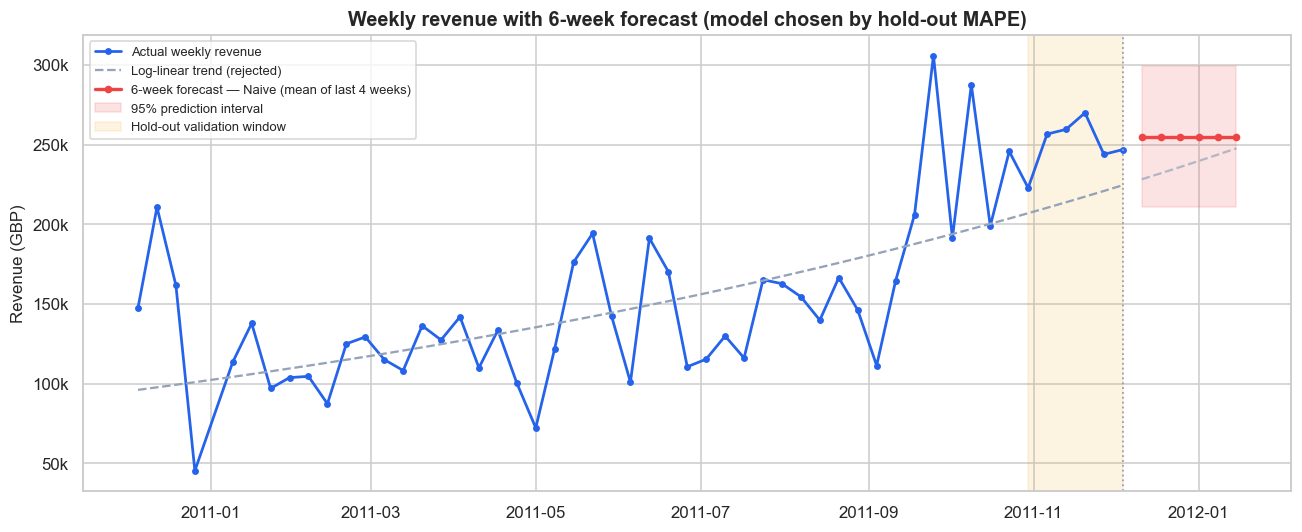

Selected model                 : Naive (mean of last 4 weeks)  (hold-out MAPE 8.5%)
Rejected model                 : Log-linear trend (hold-out MAPE 21.0%)
Mean weekly revenue (actual)   : GBP 158,101
Forecast weekly revenue        : GBP 255,003
Trend model would have said    : GBP 237,787 (-7% vs selected)


In [20]:
HORIZON = 6
future_idx = pd.date_range(weekly.index[-1] + pd.Timedelta(weeks=1), periods=HORIZON, freq="W")

# Refit the log-linear trend on the full series (kept for comparison on the chart)
t_full = week_index(weekly.index)
trend_model = LinearRegression().fit(t_full, np.log(weekly.values))
fitted = np.exp(trend_model.predict(t_full))
trend_forecast = np.exp(trend_model.predict(week_index(future_idx)))

# Use whichever model actually won on the hold-out, not whichever is more sophisticated
best_mape = scores["MAPE_%"].min()
forecast = MODELS[best](weekly, future_idx)

if best == NAIVE:
    margin = 1.96 * weekly.iloc[-8:].std(ddof=1)          # recent volatility, GBP scale
    lower, upper = forecast - margin, forecast + margin
else:
    log_forecast = trend_model.predict(week_index(future_idx))
    log_margin = 1.96 * np.std(np.log(weekly.values) - trend_model.predict(t_full), ddof=2)
    lower, upper = np.exp(log_forecast - log_margin), np.exp(log_forecast + log_margin)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(weekly.index, weekly.values, color=ACCENT, lw=1.8, marker="o", ms=3.5, label="Actual weekly revenue")
ax.plot(weekly.index, fitted, color=MUTED, ls="--", lw=1.5, label="Log-linear trend (rejected)")
ax.plot(future_idx, trend_forecast, color=MUTED, ls="--", lw=1.5, alpha=0.7)
ax.plot(future_idx, forecast, color=RED, lw=2.2, marker="o", ms=4,
        label=f"{HORIZON}-week forecast \u2014 {best}")
ax.fill_between(future_idx, lower, upper, color=RED, alpha=0.15, label="95% prediction interval")
ax.axvspan(test.index[0], weekly.index[-1], color=ACCENT2, alpha=0.12, label="Hold-out validation window")
ax.axvline(weekly.index[-1], color=MUTED, ls=":", lw=1.2)

ax.set(title=f"Weekly revenue with {HORIZON}-week forecast (model chosen by hold-out MAPE)",
       xlabel="", ylabel="Revenue (GBP)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(gbp))
ax.legend(fontsize=8.5, loc="upper left")
plt.tight_layout()
plt.savefig(f"{VIEWS}/sales_forecast.png")
plt.show()

trend_mape = scores.set_index("model").loc[TREND, "MAPE_%"]
print(f"Selected model                 : {best}  (hold-out MAPE {best_mape}%)")
print(f"Rejected model                 : {TREND} (hold-out MAPE {trend_mape}%)")
print(f"Mean weekly revenue (actual)   : GBP {weekly.mean():,.0f}")
print(f"Forecast weekly revenue        : GBP {forecast.mean():,.0f}")
print(f"Trend model would have said    : GBP {trend_forecast.mean():,.0f} "
      f"({trend_forecast.mean()/forecast.mean() - 1:+.0%} vs selected)")

**The simple baseline won, and that is the finding.** The naive "mean of the last 4 weeks" scored **8.5% MAPE**
against the log-linear trend's **21%**, so the trend model is rejected.

The *direction* of the trend model's error explains why. Fitted on Dec 2010 - Oct 2011, it smooths straight
through a seasonal pattern it has no way to represent, and therefore **under-predicts every hold-out week by
15-27%** (grey dashed line on the chart) — it cannot see the Christmas ramp coming. The naive model, anchored on
the most recent four observed weeks, simply carries the current elevated level forward and tracks the peak far
more closely.

This is worth stating plainly because the instinct is to reach for the more sophisticated model. Validation is
what settles it: on this data, a flat recent average forecasts better than a fitted trend.

**Where both models fail, and it matters:** neither can anticipate what happens *after* Christmas. The week ending
**2 Jan 2011 has exactly zero revenue** — the retailer **shuts down over Christmas and New Year**, a real operating
pattern rather than missing data. Because the forecast window begins in December, the naive model projects peak-
season revenue into a period that will collapse, so it will **over-predict January**. The forecast is credible for
the next few weeks and should not be trusted through the turn of the year.

With one year of history this cannot be fixed by tuning. It needs **2-3 years of data** so a seasonal model
(SARIMA, Prophet, or seasonal decomposition) can be fitted *and validated* rather than merely assumed. Reporting
hold-out MAPE alongside the forecast is what makes the output usable — the planner knows how much to trust it,
and over what horizon.

### Export segment assignments

In [21]:
output = customers.join(rfm[["R", "F", "M", "RFM_score", "segment", "cluster", "cluster_name"]])
output.to_csv(SEGMENT_PATH)

print(f"Saved -> {SEGMENT_PATH}  ({len(output):,} customers x {output.shape[1]} columns)")
output.head()

Saved -> ../customer_segments.csv  (4,333 customers x 17 columns)


,frequency,monetary,total_units,unique_products,country,recency,tenure,avg_order_value,is_repeat,avg_days_between_orders,R,F,M,RFM_score,segment,cluster,cluster_name
CustomerID,,,,,,,,,,,,,,,,,
12347,7,4310.00,2458,103,Iceland,2,367,615.714286,True,60.333333,5,5,5,15,Champions,2,High-Value Loyal
12348,4,1437.24,2332,21,Finland,75,358,359.310000,True,94.000000,2,4,4,10,At Risk,1,Lapsing Mid-Value
12349,1,1457.55,630,72,Italy,18,18,1457.550000,False,NaN,4,1,4,9,New / Promising,3,Active Mid-Value
12350,1,294.40,196,16,Norway,310,310,294.400000,False,NaN,1,1,2,4,Lost,0,Dormant Low-Value
12352,7,1385.74,526,57,Norway,36,296,197.962857,True,43.000000,3,5,4,12,Loyal,1,Lapsing Mid-Value


<a id="insights"></a>
## 8. Insights and recommendations

### What the data shows

**The customer base is as concentrated as the product catalogue.** 80% of revenue comes from the top **27% of
customers** — nearly identical to the 22% of products found in Part 1 — and the top **1% alone delivers 30%**.
Concentration is the defining characteristic of this business on every axis measured: product, geography, and
customer.

**The weak point is the first repeat purchase, not spending power.** 35% of customers buy exactly once and
contribute just 6.5% of revenue, yet their **average order value (£365) is essentially the same as repeat buyers'
(£383)**. Cohort retention confirms the mechanism: it falls from 100% to **~20% in month 1**, then *flattens* at
20-25%. The funnel is not leaking everywhere — it leaks at one specific transition, and customers who clear it
become durable.

**Rule-based and unsupervised segmentation agree.** RFM labels and K-Means clusters recover the same structure
independently (Champions concentrate in High-Value Loyal, Lost in Dormant), which raises confidence the segments
are real rather than artefacts of chosen thresholds. K-Means found **15.8% of customers driving 64% of revenue**.

**A naive baseline beat the trend model on forecasting.** Validated on a 6-week hold-out, the flat recent average
scored **8.5% MAPE** versus **21%** for a log-linear trend, so the trend model was rejected — it under-predicted
the Q4 peak by 15-27% because it smooths through seasonality it cannot represent. With ~12 months of data,
seasonality and trend cannot be separated. This is a limitation of the available history, not of the method.

### Recommendations

| Priority | Action | Target | Rationale |
|:--|:---|:---|:---|
| 1 | **Win the second purchase** — onboarding sequence with a time-limited incentive, triggered ~30 days after a first order | 1,505 one-time buyers + New / Promising | Retention drops to ~20% at month 1 then flattens, so converting one repeat purchase has a durable payoff. Their AOV already matches repeat buyers', so the gap is frequency, not spending power |
| 2 | **Reactivation campaign** with escalating offers | At Risk (280 customers) | Average 4.9 orders and £1,557 spend, but recency has slipped to 135 days. Proven value plus a clear trigger gives the highest expected return per contact |
| 3 | **Named-account management** — dedicated contact, early access, volume terms | Champions (1,125) / High-Value Loyal (686) | 26% of customers carry 68% of revenue; the top 1% alone carries 30%. Churn here is far costlier than in the long tail |
| 4 | **Scale fulfilment capacity from September, and plan the shutdown** | Operations | Q4 revenue is 2.6x the trough and driven by *order count*, so packing and support are the binding constraints. The zero-revenue week confirms a Christmas shutdown to staff around |
| 5 | **Fix packaging on high-return SKUs** | Product / Ops | Returns concentrate in fragile glass and ceramic candle holders (Part 1) — an operational fix, not a demand problem |
| 6 | **Stop discounting the whole base** | Marketing | With 80% of revenue in 27% of customers, uniform discounts spend most of the budget on customers who generate little revenue |
| 7 | **Forecast with a recent-average baseline until more history exists** | Planning | The naive model beat the trend model 8.5% vs 21% MAPE. Use the simple one and revisit when 2-3 years of data allow a validated seasonal model |

### Limitations

- **~12 months of data** — annual seasonality can be observed once but not validated, which caps forecast quality.
- **25% of raw rows had no `CustomerID`** and were excluded. Guest-checkout behaviour is therefore invisible to
  this analysis, and true customer counts are higher than reported here.
- **Newer cohorts have short observation windows**, so the right-hand side of the retention curve rests on fewer
  cohorts and should be read with caution.
- Segments are computed at a **single snapshot date**. In production this would be recomputed on a schedule, with
  customers expected to migrate between segments over time.

### Possible extensions
Probabilistic CLV modelling (BG/NBD + Gamma-Gamma) for expected future value per customer, market-basket
analysis for cross-sell rules, and a churn classifier once a second year of data makes a proper train/test
split across seasons possible.